# Ethiopian Food Price Forecasting — Full Pipeline

**Structure:**
1. Data Wrangling
2. EDA
3. Round 1 — Linear Regression + Random Forest (original, unfixed data)
4. Round 2 — Linear Regression, Gradient Boosting, Stacking, Random Forest (corrected data)
5. Round 3 — reserved for future iteration
6. Deep Learning — Neural Network
7. Final Comparison — every model trained so far, best model selected

Each round is self-contained: its own feature engineering, train/test split, training, evaluation, and model saving under `../models/roundN/`.

# 1. Data Wrangling

## 1.1 Load and inspect the raw dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

raw_df = pd.read_csv("../data/wfp_food_prices_sorted.csv")
print("Shape:", raw_df.shape)
print("\nMissing values:")
print(raw_df.isnull().sum())
print("\nDuplicate rows:", raw_df.duplicated().sum())
raw_df.head()

Shape: (64254, 16)

Missing values:
date            0
admin1          5
admin2          5
market          0
market_id       0
latitude        5
longitude       5
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

Duplicate rows: 0


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,120.75,15.08
1,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Sorghum (white),135,100 KG,actual,Wholesale,ETB,187.25,23.39
2,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Teff,308,100 KG,actual,Wholesale,ETB,222.00,27.73
3,2000-01-15,Addis Ababa,AA ZONE1,Addis Ababa,480,9.02,38.75,cereals and tubers,Wheat,84,100 KG,actual,Wholesale,ETB,168.75,21.08
4,2000-01-15,Amhara,Administrative unit not available,Baher Dar,482,11.60,37.38,cereals and tubers,Maize (white),67,100 KG,actual,Wholesale,ETB,115.50,14.43


**Findings:** 64,254 rows, 16 columns. Only `admin1`, `admin2`, `latitude`, `longitude` have missing values (5 rows, all the Bichena market). These aren't model features, so they're left as-is. No duplicate rows.

## 1.2 Cleaning pipeline (as a function)

Wrapped as a function with an `apply_bug_fixes` switch, so we can produce both **Round 1** (original, unfixed) and **Round 2** (corrected) versions of the cleaned dataset from the same code, without duplicating logic.

In [2]:
def clean_pipeline(df, apply_bug_fixes=True):
    """
    Cleans the raw WFP dataset: Retail-only filter, weight-unit standardization,
    non-food removal, de-duplication via priceflag, and a minimum-history threshold.

    If apply_bug_fixes=False, four source-data bugs (Wheat unit mislabeling,
    Gode Rice 2018, Sugar Nov 2022, Mechara Coffee Jan 2024) are left UNFIXED --
    this reproduces the original, flawed Round 1 pipeline on purpose.
    """
    df = df.copy()

    if apply_bug_fixes:
        rice_mask = (
            (df["commodity"] == "Rice (imported)") & (df["pricetype"] == "Retail") &
            (df["market"] == "Gode") & (df["date"].between("2018-06-01", "2018-08-31"))
        )
        df.loc[rice_mask, "price"] = df.loc[rice_mask, "price"] / 100

        sugar_mask = (
            (df["commodity"] == "Sugar") & (df["pricetype"] == "Retail") &
            (df["date"] == "2022-11-15") &
            (df["market"].isin(["Moyale", "Jijiga", "Filtu", "Charati", "Dolo Ado"])) &
            (df["price"] > 1000)
        )
        df.loc[sugar_mask, "price"] = df.loc[sugar_mask, "price"] / 100

        mechara_mask = (
            (df["commodity"] == "Coffee") & (df["pricetype"] == "Retail") &
            (df["market"] == "Mechara") & (df["date"] == "2024-01-15")
        )
        df.loc[mechara_mask, "price"] = df.loc[mechara_mask, "price"] / 10

    retail_df = df[df["pricetype"] == "Retail"].copy()

    is_wheat_100kg = (retail_df["commodity"] == "Wheat") & (retail_df["unit"] == "100 KG")
    other_100kg = (retail_df["unit"] == "100 KG") & (~is_wheat_100kg)

    if apply_bug_fixes:
        wheat_pre2020 = is_wheat_100kg & (retail_df["date"] < "2020-01-01")
        wheat_2020plus = is_wheat_100kg & (retail_df["date"] >= "2020-01-01")
        retail_df.loc[wheat_pre2020, "unit"] = "KG"
        retail_df.loc[wheat_2020plus, "price"] = retail_df.loc[wheat_2020plus, "price"] / 100
        retail_df.loc[wheat_2020plus, "unit"] = "KG"
    else:
        retail_df.loc[is_wheat_100kg, "price"] = retail_df.loc[is_wheat_100kg, "price"] / 100
        retail_df.loc[is_wheat_100kg, "unit"] = "KG"

    retail_df.loc[other_100kg, "price"] = retail_df.loc[other_100kg, "price"] / 100
    retail_df.loc[other_100kg, "unit"] = "KG"

    non_food_categories = [
        "Exchange rate (unofficial)",
        "Fuel (kerosene)", "Fuel (petrol-gasoline)", "Fuel (diesel)",
        "Wage (non-qualified labour)", "Wage (qualified labour)", "Wage (casual labour)",
        "Livestock (Sheep)", "Livestock (Goat)", "Livestock (bull)",
        "Livestock (camel)", "Livestock (cattle)", "Livestock (ox)", "Livestock (donkey)",
    ]
    food_df = retail_df[~retail_df["commodity"].isin(non_food_categories)].copy()
    food_df["date"] = pd.to_datetime(food_df["date"])

    food_df["priceflag_rank"] = food_df["priceflag"].map({"actual": 0, "aggregate": 1})
    food_df = food_df.sort_values(["date", "market", "commodity", "priceflag_rank"])
    food_df = food_df.drop_duplicates(subset=["date", "market", "commodity"], keep="first")
    food_df = food_df.drop(columns=["priceflag_rank"])

    pair_counts = food_df.groupby(["market", "commodity"]).size()
    eligible_pairs = pair_counts[pair_counts >= 24].index
    food_df = food_df.set_index(["market", "commodity"])
    food_df = food_df[food_df.index.isin(eligible_pairs)]
    food_df = food_df.reset_index()

    return food_df


# ROUND 1 source: original pipeline, bugs left in on purpose
food_df_round1 = clean_pipeline(raw_df, apply_bug_fixes=False)

# ROUND 2 source: corrected pipeline
food_df_round2 = clean_pipeline(raw_df, apply_bug_fixes=True)

print("Round 1 (unfixed) rows:", food_df_round1.shape[0])
print("Round 2 (corrected) rows:", food_df_round2.shape[0])

Round 1 (unfixed) rows: 33090
Round 2 (corrected) rows: 33090


## 1.3 How the bugs were originally found

During an early run, Random Forest produced a catastrophic validation R² of **-10.93**, with a handful of predictions in the thousands for commodities that normally trade under 200 ETB/KG. Tracing the worst errors back to their source rows revealed four real data-entry/unit problems:

1. **Wheat** — the generic "Wheat" commodity's `100 KG` unit label was wrong *before 2020* (values were already per-KG); a blanket ÷100 conversion crushed these to near-zero.
2. **Gode, Rice (imported), Jun–Aug 2018** — three rows ~100x too large.
3. **Sugar, Nov 2022, five markets** (Moyale, Jijiga, Filtu, Charati, Dolo Ado) — ~100x too large.
4. **Mechara, Coffee, Jan 2024** — one row 10x too large (4500 instead of 450).

Each was confirmed by checking neighbouring months/markets for the same commodity before applying a fix — never a blind correction. Round 1 below deliberately keeps these bugs in, to document the failure; Round 2 uses the corrected data.

## 1.4 Sanity check — volatility, Round 1 vs Round 2

In [3]:
def volatility_check(food_df, label):
    d = food_df.sort_values(["market", "commodity", "date"]).copy()
    d["pct_change"] = d.groupby(["market", "commodity"])["price"].pct_change()
    vol = d.groupby("commodity")["pct_change"].apply(lambda x: x.abs().mean())
    print(f"Top 5 most volatile commodities -- {label}:")
    print(vol.sort_values(ascending=False).head(5))
    print()

volatility_check(food_df_round1, "ROUND 1 (unfixed)")
volatility_check(food_df_round2, "ROUND 2 (corrected)")

Top 5 most volatile commodities -- ROUND 1 (unfixed):
commodity
Wheat              2.505095
Rice (imported)    0.913037
Sugar              0.750577
Sesame             0.630376
Niger seed         0.489886
Name: pct_change, dtype: float64

Top 5 most volatile commodities -- ROUND 2 (corrected):
commodity
Sesame             0.630376
Niger seed         0.489886
Wheat              0.341763
Tomatoes           0.329799
Sorghum (white)    0.307072
Name: pct_change, dtype: float64



## 1.5 Shared utility functions

Used by every round below: gap-validated lag/target creation and a chronological train/validation/test split.

In [4]:
def add_validated_lag(df, group_cols, date_col, value_col, periods, tolerance_days=3):
    """Lag feature that is NaN unless the shifted row is truly `periods` months earlier."""
    shifted_price = df.groupby(group_cols)[value_col].shift(periods)
    shifted_date = df.groupby(group_cols)[date_col].shift(periods)
    expected_days = periods * 30.44
    actual_gap = (df[date_col] - shifted_date).dt.days
    valid = actual_gap.between(
        expected_days - (10 + tolerance_days * periods),
        expected_days + (10 + tolerance_days * periods)
    )
    return shifted_price.where(valid)


def build_features(food_df):
    """Builds target_next_month_price, lag_1..lag_3, rolling stats, and date features."""
    food_df = food_df.sort_values(["market", "commodity", "date"]).copy()

    food_df["next_price"] = food_df.groupby(["market", "commodity"])["price"].shift(-1)
    food_df["next_date"] = food_df.groupby(["market", "commodity"])["date"].shift(-1)
    food_df["gap_to_next_days"] = (food_df["next_date"] - food_df["date"]).dt.days
    food_df["target_next_month_price"] = food_df["next_price"].where(
        food_df["gap_to_next_days"].between(28, 31)
    )

    group_cols = ["market", "commodity"]
    food_df["lag_1"] = add_validated_lag(food_df, group_cols, "date", "price", 1)
    food_df["lag_2"] = add_validated_lag(food_df, group_cols, "date", "price", 2)
    food_df["lag_3"] = add_validated_lag(food_df, group_cols, "date", "price", 3)

    food_df["rolling_mean_3"] = food_df[["lag_1", "lag_2", "lag_3"]].mean(axis=1, skipna=False)
    food_df["rolling_std_3"] = food_df[["lag_1", "lag_2", "lag_3"]].std(axis=1, skipna=False)

    food_df["month"] = food_df["date"].dt.month
    food_df["quarter"] = food_df["date"].dt.quarter
    food_df["year"] = food_df["date"].dt.year

    final_df = food_df[
        food_df["target_next_month_price"].notna() & food_df["rolling_mean_3"].notna()
    ].copy()
    return final_df


def chronological_split(final_df):
    """Train through 2023, Validation = 2024, Test = 2025 onward (held out)."""
    train = final_df[final_df["date"] <= "2023-12-31"]
    val = final_df[(final_df["date"] >= "2024-01-01") & (final_df["date"] <= "2024-12-31")]
    test = final_df[final_df["date"] >= "2025-01-01"]
    return train, val, test


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

feature_cols = ["market", "commodity", "lag_1", "lag_2", "lag_3",
                "rolling_mean_3", "rolling_std_3", "month", "quarter", "year"]
numeric_cols = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_std_3",
                "month", "quarter", "year"]
target_col = "target_next_month_price"

def fit_preprocessor(train_df):
    """One-hot encodes market/commodity, fit on training data only (no leakage)."""
    pre = ColumnTransformer(
        transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), ["market", "commodity"])],
        remainder="passthrough"
    )
    pre.fit(train_df[feature_cols])
    return pre


def evaluate(name, y_true, y_pred, results_list):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    results_list.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    print(f"{name}\n  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R2: {r2:.4f}")
    return mae, mse, rmse, r2

# 2. EDA

Performed on the corrected (Round 2) dataset, since this is what feeds the primary model training.

## 2.1 Dataset structure

In [5]:
print("Unique markets:", food_df_round2["market"].nunique())
print("Unique commodities:", food_df_round2["commodity"].nunique())

print("\nTop 10 commodities by number of records:")
print(food_df_round2["commodity"].value_counts().head(10))

print("\nTop 10 markets by number of records:")
print(food_df_round2["market"].value_counts().head(10))

Unique markets: 85
Unique commodities: 49

Top 10 commodities by number of records:
commodity
Maize (white)      5885
Wheat              2119
Wheat (white)      2040
Sorghum            1591
Rice               1475
Pasta              1332
Oil (vegetable)    1298
Beans (fava)       1262
Wheat flour        1234
Sorghum (white)    1176
Name: count, dtype: int64

Top 10 markets by number of records:
market
Gode        1288
Diredawa    1280
Babile      1173
Beddenno    1140
Deder       1033
Bedessa     1031
Sekota       947
Harar        919
Haromaya     901
Girawa       891
Name: count, dtype: int64


## 2.2 Long-term trend — Maize (white)

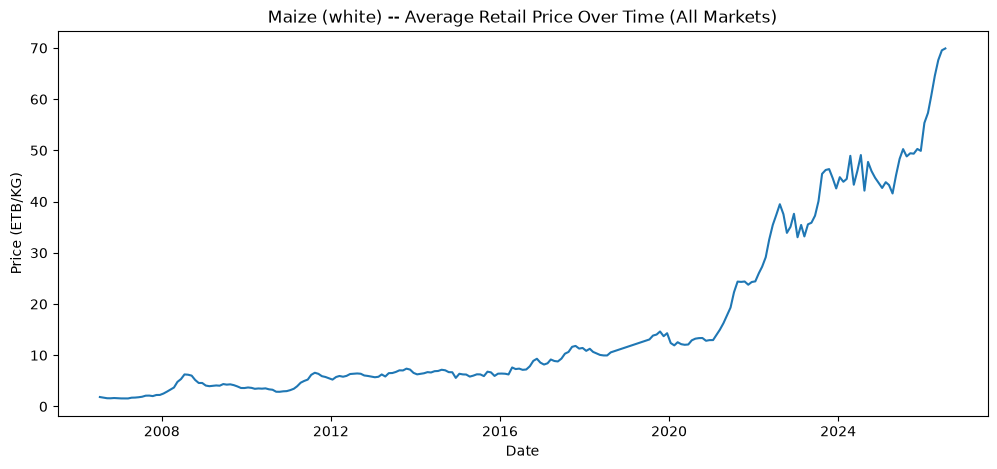

In [6]:
maize = food_df_round2[food_df_round2["commodity"] == "Maize (white)"]
maize_avg = maize.groupby("date")["price"].mean()

plt.figure(figsize=(12, 5))
plt.plot(maize_avg.index, maize_avg.values)
plt.title("Maize (white) -- Average Retail Price Over Time (All Markets)")
plt.xlabel("Date")
plt.ylabel("Price (ETB/KG)")
plt.show()

Strong, sustained inflation from 2020 onward — a real, non-stationary trend that motivates using lag/rolling features rather than a single fixed price mapping.

## 2.3 Seasonality — average price by calendar month

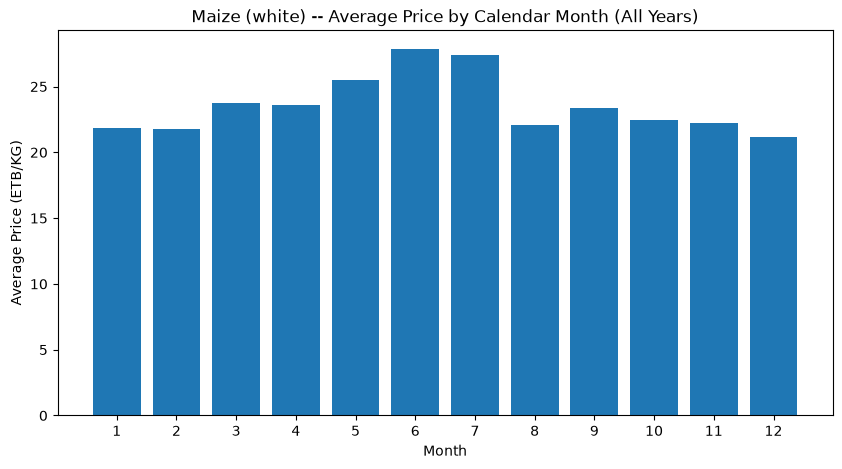

In [7]:
maize = maize.copy()
maize["month"] = maize["date"].dt.month
monthly_avg = maize.groupby("month")["price"].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title("Maize (white) -- Average Price by Calendar Month (All Years)")
plt.xlabel("Month")
plt.ylabel("Average Price (ETB/KG)")
plt.xticks(range(1, 13))
plt.show()

Prices dip after the Meher harvest (Oct-Dec) and peak in the pre-harvest lean season (Jun-Jul) — a genuine, economically meaningful seasonal signal.

## 2.4 Cold-start / data-sufficiency distribution

In [8]:
pair_counts = food_df_round2.groupby(["market", "commodity"]).size()
print("Eligible (market, commodity) pairs:", pair_counts.shape[0])
print(pair_counts.describe())

Eligible (market, commodity) pairs: 611
count    611.000000
mean      54.157119
std       28.465767
min       24.000000
25%       33.000000
50%       49.000000
75%       71.000000
max      217.000000
dtype: float64


# 3. Round 1

Trained on the **original, unfixed** data (Section 1.2). Kept deliberately, to document the failure mode caused by the four source-data bugs.

## 3.1 Feature Engineering (Round 1)

In [9]:
final_df_round1 = build_features(food_df_round1)
print("Round 1 feature-engineered rows:", final_df_round1.shape[0])

Round 1 feature-engineered rows: 18215


## 3.2 Train / Validation / Test Split (Round 1)

In [10]:
train_r1, val_r1, test_r1 = chronological_split(final_df_round1)
print("Train:", train_r1.shape[0], " Val:", val_r1.shape[0], " Test:", test_r1.shape[0])

preprocessor_r1 = fit_preprocessor(train_r1)
X_train_r1 = preprocessor_r1.transform(train_r1[feature_cols])
X_val_r1 = preprocessor_r1.transform(val_r1[feature_cols])
y_train_r1 = train_r1[target_col]
y_val_r1 = val_r1[target_col]

Train: 12074  Val: 1913  Test: 4228


## 3.3 Training — Linear Regression (Round 1)

In [11]:
lr_round1 = LinearRegression()
lr_round1.fit(X_train_r1, y_train_r1)
print("Linear Regression (Round 1) trained.")

Linear Regression (Round 1) trained.


## 3.4 Evaluation Metrics — Linear Regression (Round 1)

In [12]:
round1_results = []
pred_lr_r1 = lr_round1.predict(X_val_r1)
evaluate("Round 1 - Linear Regression", y_val_r1, pred_lr_r1, round1_results)

Round 1 - Linear Regression
  MAE: 21.75  RMSE: 53.82  R2: 0.6424


(21.748154210851773,
 2896.7410421400705,
 np.float64(53.82138090146025),
 0.6424017863941531)

## 3.5 Training — Random Forest (Round 1)

In [13]:
rf_round1 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_round1.fit(X_train_r1, y_train_r1)
print("Random Forest (Round 1) trained.")

Random Forest (Round 1) trained.


## 3.6 Evaluation Metrics — Random Forest (Round 1)

In [14]:
pred_rf_r1 = rf_round1.predict(X_val_r1)
evaluate("Round 1 - Random Forest", y_val_r1, pred_rf_r1, round1_results)

Round 1 - Random Forest
  MAE: 44.18  RMSE: 312.68  R2: -11.0691


(44.180527466544696,
 97766.16809033266,
 np.float64(312.6758194845464),
 -11.06908265240141)

## 3.7 Comparison — Linear Regression vs Random Forest (Round 1)

In [15]:
round1_df = pd.DataFrame(round1_results).sort_values("MAE")
round1_df

,Model,MAE,MSE,RMSE,R2
0,Round 1 - Linear Regression,21.748154,2896.741042,53.821381,0.642402
1,Round 1 - Random Forest,44.180527,97766.168090,312.675819,-11.069083


**Expected result:** Random Forest shows a strongly negative R² here — the clearest demonstration of how a handful of bad source rows can break a tree-based model even when the average error (MAE) looks only moderately bad.

## 3.8 Save Round 1 models

In [16]:
os.makedirs("../models/round1", exist_ok=True)

joblib.dump(lr_round1, "../models/round1/linear_regression_round1.joblib")
joblib.dump(rf_round1, "../models/round1/random_forest_round1.joblib")
joblib.dump(preprocessor_r1, "../models/round1/preprocessor_round1.joblib")
round1_df.to_csv("../models/round1/round1_results.csv", index=False)

print("Round 1 saved:", os.listdir("../models/round1"))

Round 1 saved: ['linear_regression_round1.joblib', 'preprocessor_round1.joblib', 'random_forest_round1.joblib', 'round1_results.csv']


# 4. Round 2

Trained on the **corrected** data (Section 1.2). Four classical models: Linear Regression, Gradient Boosting, Stacking, and Random Forest.

## 4.1 Feature Engineering (Round 2)

In [17]:
final_df_round2 = build_features(food_df_round2)
print("Round 2 feature-engineered rows:", final_df_round2.shape[0])

Round 2 feature-engineered rows: 18215


## 4.2 Train / Validation / Test Split (Round 2)

In [18]:
train_r2, val_r2, test_r2 = chronological_split(final_df_round2)
print("Train:", train_r2.shape[0], " Val:", val_r2.shape[0], " Test:", test_r2.shape[0])

preprocessor_r2 = fit_preprocessor(train_r2)
X_train_r2 = preprocessor_r2.transform(train_r2[feature_cols])
X_val_r2 = preprocessor_r2.transform(val_r2[feature_cols])
y_train_r2 = train_r2[target_col]
y_val_r2 = val_r2[target_col]

Train: 12074  Val: 1913  Test: 4228


## 4.3 Training — Linear Regression (Round 2)

In [19]:
lr_round2 = LinearRegression()
lr_round2.fit(X_train_r2, y_train_r2)
print("Linear Regression (Round 2) trained.")

Linear Regression (Round 2) trained.


## 4.4 Evaluation Metrics — Linear Regression (Round 2)

In [20]:
round2_results = []
pred_lr_r2 = lr_round2.predict(X_val_r2)
evaluate("Round 2 - Linear Regression", y_val_r2, pred_lr_r2, round2_results)

Round 2 - Linear Regression
  MAE: 11.92  RMSE: 20.74  R2: 0.9469


(11.91559006762036,
 430.2929878493075,
 np.float64(20.74350471471269),
 0.9468809943506872)

## 4.5 Training — Gradient Boosting (Round 2)

In [21]:
gb_round2 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_round2.fit(X_train_r2, y_train_r2)
print("Gradient Boosting (Round 2) trained.")

Gradient Boosting (Round 2) trained.


## 4.6 Evaluation Metrics — Gradient Boosting (Round 2)

In [22]:
pred_gb_r2 = gb_round2.predict(X_val_r2)
evaluate("Round 2 - Gradient Boosting", y_val_r2, pred_gb_r2, round2_results)

Round 2 - Gradient Boosting
  MAE: 11.60  RMSE: 19.72  R2: 0.9520


(11.598609721897606,
 388.9024034396015,
 np.float64(19.72060859708953),
 0.9519905981536139)

## 4.7 Training — Stacking (Round 2)

In [23]:
base_learners = [
    ("rf", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("gb", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))
]
stack_round2 = StackingRegressor(estimators=base_learners, final_estimator=Ridge(), n_jobs=-1)
stack_round2.fit(X_train_r2, y_train_r2)
print("Stacking (Round 2) trained.")

Stacking (Round 2) trained.


## 4.8 Evaluation Metrics — Stacking (Round 2)

In [24]:
pred_stack_r2 = stack_round2.predict(X_val_r2)
evaluate("Round 2 - Stacking", y_val_r2, pred_stack_r2, round2_results)

Round 2 - Stacking
  MAE: 11.81  RMSE: 19.95  R2: 0.9509


(11.809399233044893,
 398.1262014737348,
 np.float64(19.95310004670289),
 0.950851934513446)

## 4.9 Training — Random Forest (Round 2)

In [25]:
rf_round2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_round2.fit(X_train_r2, y_train_r2)
print("Random Forest (Round 2) trained.")

Random Forest (Round 2) trained.


## 4.10 Evaluation Metrics — Random Forest (Round 2)

In [26]:
pred_rf_r2 = rf_round2.predict(X_val_r2)
evaluate("Round 2 - Random Forest", y_val_r2, pred_rf_r2, round2_results)

Round 2 - Random Forest
  MAE: 12.39  RMSE: 20.65  R2: 0.9474


(12.394498923680084,
 426.2278075820145,
 np.float64(20.6452853596654),
 0.9473828345843919)

## 4.11 Comparison — all 4 Round 2 models

In [27]:
round2_df = pd.DataFrame(round2_results).sort_values("MAE")
round2_df

,Model,MAE,MSE,RMSE,R2
1,Round 2 - Gradient Boosting,11.598610,388.902403,19.720609,0.951991
2,Round 2 - Stacking,11.809399,398.126201,19.953100,0.950852
0,Round 2 - Linear Regression,11.915590,430.292988,20.743505,0.946881
3,Round 2 - Random Forest,12.394499,426.227808,20.645285,0.947383


## 4.12 Save Round 2 models

In [28]:
os.makedirs("../models/round2", exist_ok=True)

joblib.dump(lr_round2, "../models/round2/linear_regression.joblib")
joblib.dump(gb_round2, "../models/round2/gradient_boosting.joblib")
joblib.dump(stack_round2, "../models/round2/stacking.joblib")
joblib.dump(rf_round2, "../models/round2/random_forest.joblib")
joblib.dump(preprocessor_r2, "../models/round2/preprocessor_round2.joblib")
round2_df.to_csv("../models/round2/round2_results.csv", index=False)

print("Round 2 saved:", os.listdir("../models/round2"))

Round 2 saved: ['gradient_boosting.joblib', 'linear_regression.joblib', 'preprocessor_round2.joblib', 'random_forest.joblib', 'round2_results.csv', 'stacking.joblib']


# 5. Round 3 (if it exists)

**Reserved for a future iteration** — e.g. hyperparameter tuning of the Round 2 models, additional features (lag_6, holiday/conflict indicators), or trying a different eligibility threshold. No Round 3 has been run yet, so there is nothing to train, evaluate, or save here. If a Round 3 is added later, it should follow the same pattern as Rounds 1 and 2: its own feature engineering, split, training, evaluation, and a save step under `../models/round3/`.

# 6. Deep Learning

A Dense Neural Network, trained on the same corrected (Round 2) data. Uses scaled numeric features plus the Round 2 one-hot categorical encoding. `EarlyStopping` halts training once validation loss stops improving for 10 epochs and restores the best-performing weights, avoiding the overfitting seen in an earlier fixed-epoch run.

## 6.1 Prepare inputs

In [29]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(train_r2[numeric_cols])
X_val_numeric_scaled = scaler.transform(val_r2[numeric_cols])

cat_encoder = preprocessor_r2.named_transformers_["cat"]
X_train_cat = cat_encoder.transform(train_r2[["market", "commodity"]])
X_val_cat = cat_encoder.transform(val_r2[["market", "commodity"]])

X_train_nn = np.hstack([X_train_cat.toarray(), X_train_numeric_scaled])
X_val_nn = np.hstack([X_val_cat.toarray(), X_val_numeric_scaled])

print("NN input shape:", X_train_nn.shape)

NN input shape: (12074, 137)


## 6.2 Training — Neural Network

In [30]:
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
nn_model.compile(optimizer="adam", loss="mae")

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train_nn, y_train_r2,
    validation_data=(X_val_nn, y_val_r2),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21.0346 - val_loss: 13.6172
Epoch 2/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2475 - val_loss: 12.9027
Epoch 3/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9409 - val_loss: 12.9602
Epoch 4/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7937 - val_loss: 12.5097
Epoch 5/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7256 - val_loss: 12.7949
Epoch 6/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.6271 - val_loss: 12.3379
Epoch 7/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5784 - val_loss: 13.3213
Epoch 8/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.5264 - val_loss: 12.3627
Epoch 9/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.4753 - val_loss: 13.2091
Epoch 10/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.4431 - val_loss: 12.3365
Epoch 11/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.4139 - val_loss: 12.8727
Epoch 12/100
378/378 ━━━━━━━━

## 6.3 Evaluation Metrics — Neural Network

In [31]:
dl_results = []
pred_nn = nn_model.predict(X_val_nn).flatten()
evaluate("Deep Learning - Neural Network", y_val_r2, pred_nn, dl_results)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Deep Learning - Neural Network
  MAE: 12.14  RMSE: 21.22  R2: 0.9444


(12.140403661364383,
 450.18158411775244,
 np.float64(21.217482982619604),
 0.9444257778182941)

## 6.4 Save the Neural Network

In [32]:
os.makedirs("../models/deep_learning", exist_ok=True)

joblib.dump(scaler, "../models/deep_learning/scaler_numeric.joblib")
nn_model.save("../models/deep_learning/neural_network.keras")

print("Neural Network saved:", os.listdir("../models/deep_learning"))

Neural Network saved: ['deep_learning_results.csv', 'lstm.keras', 'neural_network.keras', 'scaler_numeric.joblib']


## 6.5 Prepare sequence inputs for LSTM

The LSTM needs its input shaped as an actual **sequence** (samples, timesteps, features), not flat lag columns. We reuse the already-scaled `lag_1`, `lag_2`, `lag_3` values from the Dense NN's numeric scaler (columns 0-2 of `X_train_numeric_scaled`), reordered chronologically (`lag_3` -> `lag_2` -> `lag_1`, i.e. oldest to newest) as a 3-timestep, 1-feature sequence. Market/commodity one-hot encoding and month/quarter/year are kept as separate **static** inputs, merged with the LSTM's output before the final prediction layer -- this lets the model use both the price trajectory and the context (which market, which commodity, which season).

In [33]:
# Sequence input: [lag_3, lag_2, lag_1] in chronological order -> shape (samples, 3, 1)
seq_col_idx = [2, 1, 0]  # numeric_cols[2]=lag_3, [1]=lag_2, [0]=lag_1
X_train_seq = X_train_numeric_scaled[:, seq_col_idx].reshape(-1, 3, 1)
X_val_seq = X_val_numeric_scaled[:, seq_col_idx].reshape(-1, 3, 1)

# Static input: market/commodity one-hot + scaled month, quarter, year
static_col_idx = [5, 6, 7]  # numeric_cols[5]=month, [6]=quarter, [7]=year
X_train_static = np.hstack([X_train_cat.toarray(), X_train_numeric_scaled[:, static_col_idx]])
X_val_static = np.hstack([X_val_cat.toarray(), X_val_numeric_scaled[:, static_col_idx]])

print("Sequence input shape:", X_train_seq.shape)
print("Static input shape:", X_train_static.shape)

Sequence input shape: (12074, 3, 1)
Static input shape: (12074, 132)


## 6.6 Training — LSTM

In [34]:
seq_input = layers.Input(shape=(3, 1), name="price_sequence")
lstm_out = layers.LSTM(32)(seq_input)

static_input = layers.Input(shape=(X_train_static.shape[1],), name="static_features")
merged = layers.Concatenate()([lstm_out, static_input])
x = layers.Dense(32, activation="relu")(merged)
output = layers.Dense(1)(x)

lstm_model = keras.Model(inputs=[seq_input, static_input], outputs=output)
lstm_model.compile(optimizer="adam", loss="mae")

early_stop_lstm = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history_lstm = lstm_model.fit(
    [X_train_seq, X_train_static], y_train_r2,
    validation_data=([X_val_seq, X_val_static], y_val_r2),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

Epoch 1/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 33.4486 - val_loss: 34.3154
Epoch 2/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 11.6229 - val_loss: 20.1086
Epoch 3/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.6187 - val_loss: 16.3278
Epoch 4/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.8985 - val_loss: 12.8627
Epoch 5/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8887 - val_loss: 11.7241
Epoch 6/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.6362 - val_loss: 11.9570
Epoch 7/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5673 - val_loss: 11.7131
Epoch 8/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.5250 - val_loss: 11.7310
Epoch 9/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.5152 - val_loss: 12.4560
Epoch 10/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.4717 - val_loss: 11.7430
Epoch 11/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4870 - val_loss: 11.5239
Epoch 12/100
378/378 ━━━━━━━

## 6.7 Evaluation Metrics — LSTM

In [35]:
pred_lstm = lstm_model.predict([X_val_seq, X_val_static]).flatten()
evaluate("Deep Learning - LSTM", y_val_r2, pred_lstm, dl_results)

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Deep Learning - LSTM
  MAE: 11.43  RMSE: 20.63  R2: 0.9475


(11.429726043488202,
 425.40434857587326,
 np.float64(20.625332690065225),
 0.9474844893285648)

## 6.8 Save the LSTM

In [36]:
lstm_model.save("../models/deep_learning/lstm.keras")
print("LSTM saved to ../models/deep_learning/lstm.keras")

LSTM saved to ../models/deep_learning/lstm.keras


## 6.9 Deep Learning comparison — Neural Network vs LSTM

In [37]:
dl_df = pd.DataFrame(dl_results).sort_values("MAE")
dl_df.to_csv("../models/deep_learning/deep_learning_results.csv", index=False)
dl_df

,Model,MAE,MSE,RMSE,R2
1,Deep Learning - LSTM,11.429726,425.404349,20.625333,0.947484
0,Deep Learning - Neural Network,12.140404,450.181584,21.217483,0.944426


**Note:** the LSTM here only sees the same 3-month price history already used by the Dense NN's `lag_1/2/3` features -- it doesn't have more raw information, just a different architecture for processing it (a recurrent layer instead of flat dense layers). Whether it outperforms the plain Dense NN is therefore a genuine architecture comparison, not a data-availability difference.

# 7. Final Comparison — All Models

Every model trained across Round 1, Round 2, and Deep Learning, compared side by side on the same validation period (2024), with the best model selected by MAE.

In [38]:
all_results = pd.concat([round1_df, round2_df, dl_df], ignore_index=True)
all_results = all_results.sort_values("MAE").reset_index(drop=True)
all_results

,Model,MAE,MSE,RMSE,R2
0,Deep Learning - LSTM,11.429726,425.404349,20.625333,0.947484
1,Round 2 - Gradient Boosting,11.598610,388.902403,19.720609,0.951991
2,Round 2 - Stacking,11.809399,398.126201,19.953100,0.950852
3,Round 2 - Linear Regression,11.915590,430.292988,20.743505,0.946881
4,Deep Learning - Neural Network,12.140404,450.181584,21.217483,0.944426
5,Round 2 - Random Forest,12.394499,426.227808,20.645285,0.947383
6,Round 1 - Linear Regression,21.748154,2896.741042,53.821381,0.642402
7,Round 1 - Random Forest,44.180527,97766.168090,312.675819,-11.069083


In [39]:
best_model_row = all_results.iloc[0]
best_mae = best_model_row["MAE"]
best_rmse = best_model_row["RMSE"]
best_r2 = best_model_row["R2"]
print("Best model overall:", best_model_row["Model"])
print(f"MAE: {best_mae:.2f}  RMSE: {best_rmse:.2f}  R2: {best_r2:.4f}")

all_results.to_csv("../models/final_comparison.csv", index=False)
print("\nSaved final comparison table to ../models/final_comparison.csv")

Best model overall: Deep Learning - LSTM
MAE: 11.43  RMSE: 20.63  R2: 0.9475

Saved final comparison table to ../models/final_comparison.csv


## Notes for the project report

- **Round 1** (`models/round1/`) documents the original pipeline before four source-data bugs were fixed. Random Forest's catastrophic negative R² here is the key evidence that motivated the investigation described in Section 1.3.
- **Round 2** (`models/round2/`) holds the four classical models trained on the corrected data.
- **Round 3** is reserved for a future iteration (e.g. hyperparameter tuning) — not yet run.
- **Deep Learning** (`models/deep_learning/`) holds the early-stopped Dense Neural Network.
- The final comparison table above combines every model trained so far and identifies the current best performer on the validation set.
- Per proper methodology, the held-out **test set (2025-2026)** should be evaluated once, only after the final model is locked in — not used for repeated tuning.